In [ ]:
json_train_path = './noisy_CWWS_train_small.json'

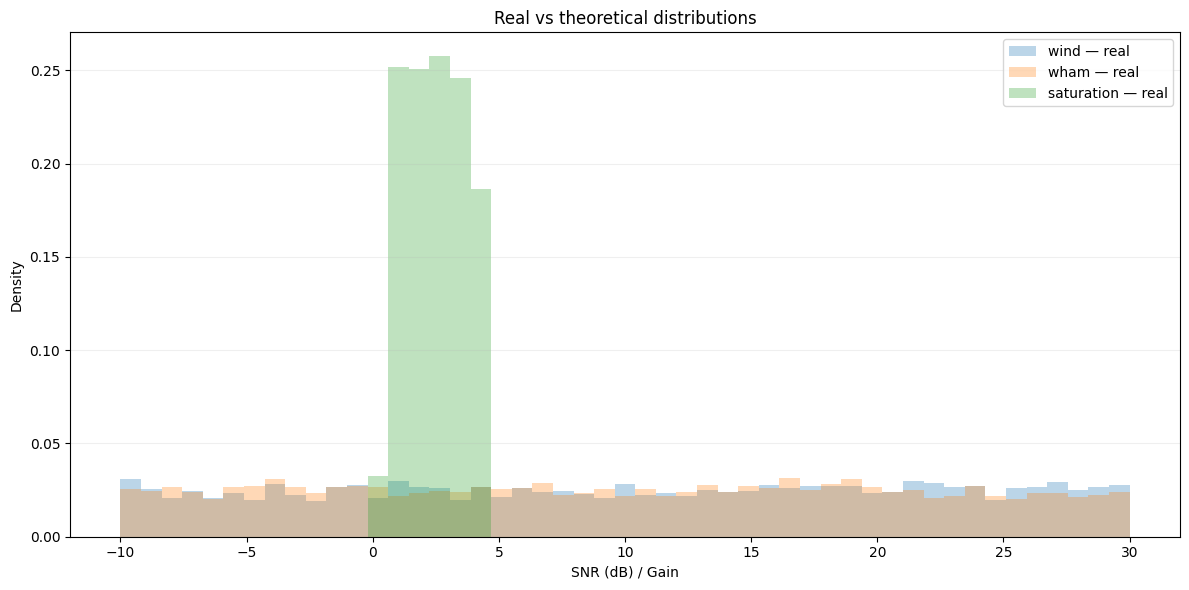

In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import triang

# --------------------------------------------------
# Load JSON
# --------------------------------------------------
with open(json_train_path, "r") as f:
    config = json.load(f)

df = pd.DataFrame(config["data"])

# --------------------------------------------------
# Group noise types
# --------------------------------------------------
df["noise_group"] = np.select(
    [
        df["noise"].str.contains("wham", case=False, na=False),
        df["noise"].eq("wind"),
        df["noise"].eq("saturation"),
    ],
    [
        "wham",
        "wind",
        "saturation",
    ],
    default=None
)

df = df.dropna(subset=["noise_group"])


# --------------------------------------------------
# Define the value to plot
#
# wind / wham -> snr_db
# saturation  -> gain
# --------------------------------------------------
df["plot_value"] = np.where(
    df["noise_group"].eq("saturation"),
    df["gain"],
    df["snr_db"]
)

df = df.dropna(subset=["plot_value"])


# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))

colors = {
    "wind": "tab:blue",
    "wham": "tab:orange",
    "saturation": "tab:green",
}


# --------------------------------------------------
# Real distributions
# --------------------------------------------------

# Use common bins covering both SNR and gain
bins = np.linspace(
    df["plot_value"].min(),
    df["plot_value"].max(),
    50
)

for noise in ["wind", "wham", "saturation"]:

    values = df.loc[
        df["noise_group"] == noise,
        "plot_value"
    ]

    ax.hist(
        values,
        bins=bins,
        density=True,
        alpha=0.30,
        color=colors[noise],
        label=f"{noise} — real"
    )


# --------------------------------------------------
# Theoretical SNR distributions
# --------------------------------------------------
sampler_info = config["sampler_info"]

theoretical_ranges = {
    "wind": sampler_info["wind_snr_range"],
    "wham": sampler_info["wham_snr_range"],
}

# --------------------------------------------------
# Formatting
# --------------------------------------------------
ax.set_xlabel("SNR (dB) / Gain")
ax.set_ylabel("Density")
ax.set_title("Real vs theoretical distributions")

ax.grid(axis="y", alpha=0.2)
ax.legend()

plt.tight_layout()
plt.show()